# EconAgent — Análisis de resultados (Nova Lite / Bedrock)

Análisis de la corrida con `amazon.nova-lite-v1:0` vía Bedrock (`ECON_BACKEND=bedrock`), 100 agentes, 240 meses.

Mismo formato que `analysis.ipynb` (corrida original con gpt-3.5-turbo-0613), para poder comparar resultados entre modelos. Los archivos en `data/` son todos generados por la corrida, salvo `profiles.json` que se genera al inicio (se sospecha con alguna base de datos de estadísticas gubernamentales).

In [23]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 4)

# Examinamos los archivos

 Descripción de Archivos

| Archivo / Carpeta | Descripción |
| :--- | :--- |
| `env_6.pkl`, `env_12.pkl` | El objeto `env` completo (estado de Foundation) serializado en el paso 6 y 12. |
| `obs_6.pkl`, `obs_12.pkl` | La observación devuelta por el `env` en ese paso. |
| `actions_6.pkl`, `actions_12.pkl` | Las acciones `[work, consumption]` decodificadas del JSON del LLM para cada agente. |
| `dialog_6.pkl`, `dialog_12.pkl` | La cola corta de diálogo (`dialog_queue`, `maxlen=3`) que se manda como contexto al LLM en cada llamada. |
| `dialog4ref_6.pkl`, `dialog4ref_12.pkl` | La cola larga de diálogo (`maxlen=7`) que alimenta las reflexiones trimestrales. |
| `dense_log.pkl`, `dense_log_6.pkl`, `dense_log_12.pkl` | El log denso de Foundation: histórico completo de estados/acciones/recompensas de la simulación, paso a paso (esto es lo que analiza este notebook). |
| `dialogs/` | Carpeta con un archivo de texto por agente (nombre del agente = nombre del archivo), con el historial completo de la conversación en texto plano (lo que escribe `simulate.py:127-130`) — útil para leer "a mano" qué le contestó el LLM a cada agente mes a mes. |

**Nota sobre el nombre de la carpeta**: `simulate.py` arma el nombre de la carpeta de resultados como `{policy_model}-{dialog_len}-noperception-reflection-1-{num_agents}agents-{episode_length}months` — no incluye el backend ni el modelo (`ECON_BACKEND` / `BEDROCK_MODEL_ID` / `OPENAI_MODEL`). Por eso una corrida con gpt-3.5-turbo-0613 y otra con Nova Lite, ambas con los mismos `num_agents`/`episode_length`, caerían en la **misma carpeta** y se pisarían. Esta corrida (Nova Lite, terminada 2026-08-26 01:11) es la única que hay actualmente en `gpt-3-noperception-reflection-1-100agents-240months/` — si corrés otro modelo con la misma config, hacé una copia de esta carpeta antes.

## 1. Cargar resultados

In [24]:
# Listá las simulaciones disponibles
data_dir = Path('data')
runs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
for i, r in enumerate(runs):
    print(f'[{i}] {r.name}')

[0] gpt-3-noperception-reflection-1-100agents-120months
[1] gpt-3-noperception-reflection-1-100agents-240months
[2] gpt-3-noperception-reflection-1-100agents-48months
[3] gpt-3-noperception-reflection-1-100agents-54months
[4] gpt-3-noperception-reflection-1-40agents-48months


In [25]:
# Esta corrida es Nova Lite vía Bedrock (100 agentes, 240 meses, dialog_len=3)
RUN_NAME = 'gpt-3-noperception-reflection-1-100agents-240months'
run_path = next(r for r in runs if r.name == RUN_NAME)
print(f'Analizando: {run_path.name}')

with open(run_path / 'dense_log.pkl', 'rb') as f:
    log = pkl.load(f)

print('\nClaves disponibles en dense_log:')
print(list(log.keys()))

Analizando: gpt-3-noperception-reflection-1-100agents-240months

Claves disponibles en dense_log:
['world', 'states', 'actions', 'rewards', 'PeriodicTax']


**Metadata de la corrida** (de la consola al terminar):
- Backend: `bedrock` — modelo: `amazon.nova-lite-v1:0`
- 100 agentes, 240 meses, `dialog_len=3`
- 0 errores de parseo (`#errors: 0`)
- Costo reportado por consola: **$149.21** ⚠️ **NO ES CONFIABLE** — ver nota abajo
- Duración real: ~3h (22:21 → 01:11)

**⚠️ Bug de pricing**: el costo se calcula con `PRICE_INPUT_PER_1M` / `PRICE_OUTPUT_PER_1M` en `.env`, que en esta corrida seguían seteados en **$3 / $15 por 1M tokens (precio de Claude Sonnet 4.6)**, no el de Nova Lite (que en Bedrock ronda $0.06 / $0.24 por 1M — unas 50x más barato). El costo real de esta corrida probablemente fue de un par de dólares, no $149. Para comparar costos entre modelos hay que corregir esas variables (o agregar `amazon.nova-lite-v1:0` al diccionario `PRICING` de `llm_providers.py`) antes de la próxima corrida.

In [26]:
from pprint import pprint

actions_6_path = run_path / 'actions_6.pkl'

if actions_6_path.exists():
    with open(actions_6_path, 'rb') as f:
        actions_6 = pkl.load(f)
    print(f'Archivo cargado: {actions_6_path.name}')
else:
    actions_6 = log.get('actions_6', None)
    print('No se encontró actions_6.pkl; usando log["actions_6"] si existe.')

print('Tipo:', type(actions_6))

if isinstance(actions_6, pd.DataFrame):
    display(actions_6)
elif isinstance(actions_6, (list, tuple)):
    pprint(actions_6[:5])
    print(f'Longitud: {len(actions_6)}')
elif isinstance(actions_6, dict):
    pprint(actions_6)
else:
    print(actions_6)

Archivo cargado: actions_6.pkl
Tipo: <class 'dict'>
{'0': [1, 49.0],
 '1': [1, 49.0],
 '10': [1, 49.0],
 '11': [1, 49.0],
 '12': [1, 49.0],
 '13': [1, 49.0],
 '14': [1, 49.0],
 '15': [1, 50.0],
 '16': [1, 33.0],
 '17': [1, 49.0],
 '18': [1, 49.0],
 '19': [1, 49.0],
 '2': [1, 48.0],
 '20': [1, 49.0],
 '21': [1, 49.0],
 '22': [1, 49.0],
 '23': [1, 49.0],
 '24': [1, 49.0],
 '25': [1, 49.0],
 '26': [1, 49.0],
 '27': [1, 49.0],
 '28': [1, 49.0],
 '29': [1, 49.0],
 '3': [0, 46.99999999999999],
 '30': [1, 49.0],
 '31': [1, 49.0],
 '32': [1, 46.99999999999999],
 '33': [1, 49.0],
 '34': [1, 48.0],
 '35': [1, 44.0],
 '36': [1, 49.0],
 '37': [1, 49.0],
 '38': [1, 25.0],
 '39': [1, 49.0],
 '4': [1, 49.0],
 '40': [1, 49.0],
 '41': [1, 50.0],
 '42': [1, 8.0],
 '43': [1, 49.0],
 '44': [1, 49.0],
 '45': [1, 49.0],
 '46': [1, 49.0],
 '47': [1, 49.0],
 '48': [1, 46.99999999999999],
 '49': [1, 49.0],
 '5': [1, 49.0],
 '50': [1, 49.0],
 '51': [1, 50.0],
 '52': [1, 38.0],
 '53': [1, 49.0],
 '54': [1, 49.0]

archivo actions_6.pkl muestra los agentes y el gobierno (p de planner) con las decisiones de trabajo/consumo del mes 6.
### 1. El LLM devuelve un porcentaje (0 a 1)
El prompt le pide al LLM: "'consumption' (a value between 0 and 1 with intervals of 0.02)" — es decir, algo como 0.5 = "quiero gastar el 50% de mis ahorros+ingreso disponible en bienes esenciales".

### 2. simulate.py convierte ese porcentaje en un índice discreto

extracted_actions[1] /= 0.02
(simulate.py:122)

Si el LLM contestó consumption = 0.5, esto hace 0.5 / 0.02 = 25. Ese 25 es el número que terminás viendo guardado en actions_6.pkl. No es "25 dólares" ni "25%" — es un índice de acción discreta dentro de una grilla de 50 posiciones (n_actions = 1.0/0.02 = 50, simple_consumption.py:35).

### 3. Foundation vuelve a convertir ese índice en tasa real
Cuando Foundation ejecuta el step, el componente SimpleConsumption toma esa acción (action=25) y hace la operación inversa:


consumption_rate = action * self.consumption_rate_step   # 25 * 0.02 = 0.5
(simple_consumption.py:84)

Es decir: 25 × 0.02 = 0.5 → 50% de la tasa de consumo, que es exactamente el mismo porcentaje que el LLM dijo originalmente en el prompt.

Por qué existe este ida y vuelta
Foundation (heredado del paper RL original) espera acciones discretas porque las redes de política PPO tienen una cabeza de clasificación (softmax sobre 50 categorías), no un valor continuo. El LLM en cambio razona más naturalmente en porcentajes continuos (0 a 1). Entonces:

LLM → índice: se divide por 0.02 para "encajar" la respuesta continua del LLM en la grilla discreta de 50 acciones que espera el motor de Foundation.
índice → efecto real: Foundation multiplica por 0.02 de vuelta para recuperar la tasa real y calcular cuánto dinero gasta el agente ese mes.
En resumen: el valor guardado en el .pkl es un artefacto de codificación intermedio (el índice de acción), y su significado económico real es simplemente índice × 0.02 = proporción gastada ese mes.

## 2. Extraer series de tiempo

In [27]:
T = len(log['states'])
n_agents = len([k for k in log['states'][0].keys() if k != 'p'])
print(f'Pasos: {T}   Agentes: {n_agents}')

# --- Macroeconómicos (world) ---
world_df = pd.DataFrame(log['world'])
world_df.index.name = 'step'

# --- Estados de agentes ---
wealth    = np.array([[log['states'][t][str(i)]['inventory']['Coin']  for i in range(n_agents)] for t in range(T)])
income    = np.array([[log['states'][t][str(i)].get('income', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
skill     = np.array([[log['states'][t][str(i)]['skill']               for i in range(n_agents)] for t in range(T)])

print('world_df columnas:', list(world_df.columns))

Pasos: 241   Agentes: 100
world_df columnas: ['Price', '#Products', 'Interest Rate', 'Unemployment Rate', 'Real GDP', 'Nominal GDP', 'Price Inflation', 'Unemployment Rate Growth', 'Wage Inflation', 'Nominal GDP Growth', 'Real GDP Growth']


## 3. Indicadores macroeconómicos

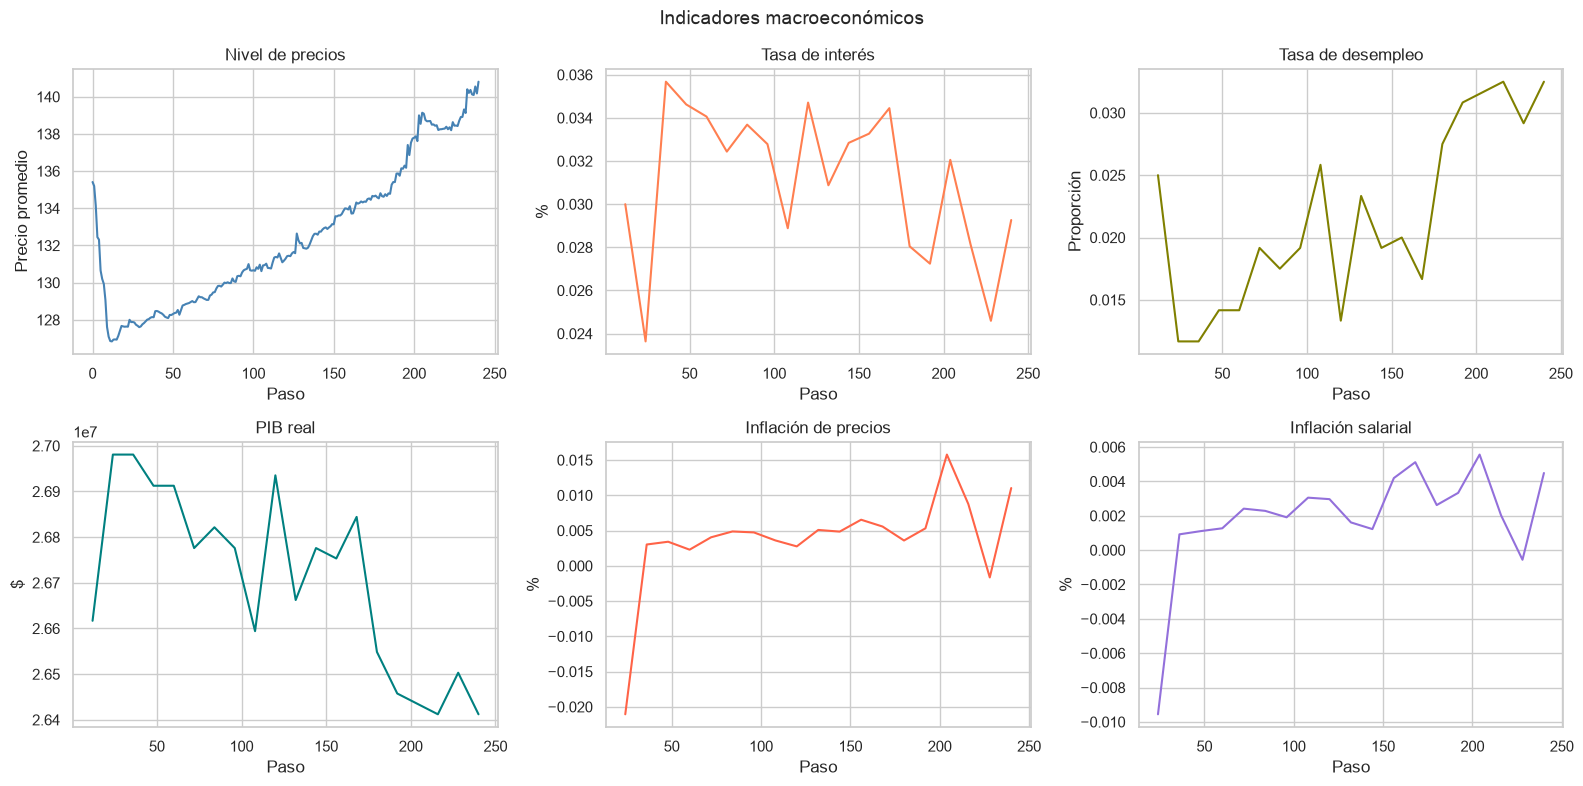

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Indicadores macroeconómicos', fontsize=14)
steps = range(T)

def plot_series(ax, series, title, ylabel, color='steelblue'):
    clean = series.dropna()
    ax.plot(clean.index, clean.values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Paso')

plot_series(axes[0,0], world_df['Price'],           'Nivel de precios',      'Precio promedio')
plot_series(axes[0,1], world_df.get('Interest Rate', pd.Series(dtype=float)), 'Tasa de interés', '%', color='coral')
plot_series(axes[0,2], world_df.get('Unemployment Rate', pd.Series(dtype=float)), 'Tasa de desempleo', 'Proporción', color='olive')
plot_series(axes[1,0], world_df.get('Real GDP', pd.Series(dtype=float)),       'PIB real',      '$', color='teal')
plot_series(axes[1,1], world_df.get('Price Inflation', pd.Series(dtype=float)), 'Inflación de precios', '%', color='tomato')
plot_series(axes[1,2], world_df.get('Wage Inflation', pd.Series(dtype=float)),  'Inflación salarial',  '%', color='mediumpurple')

plt.tight_layout()
plt.show()

## 4. Distribución de riqueza

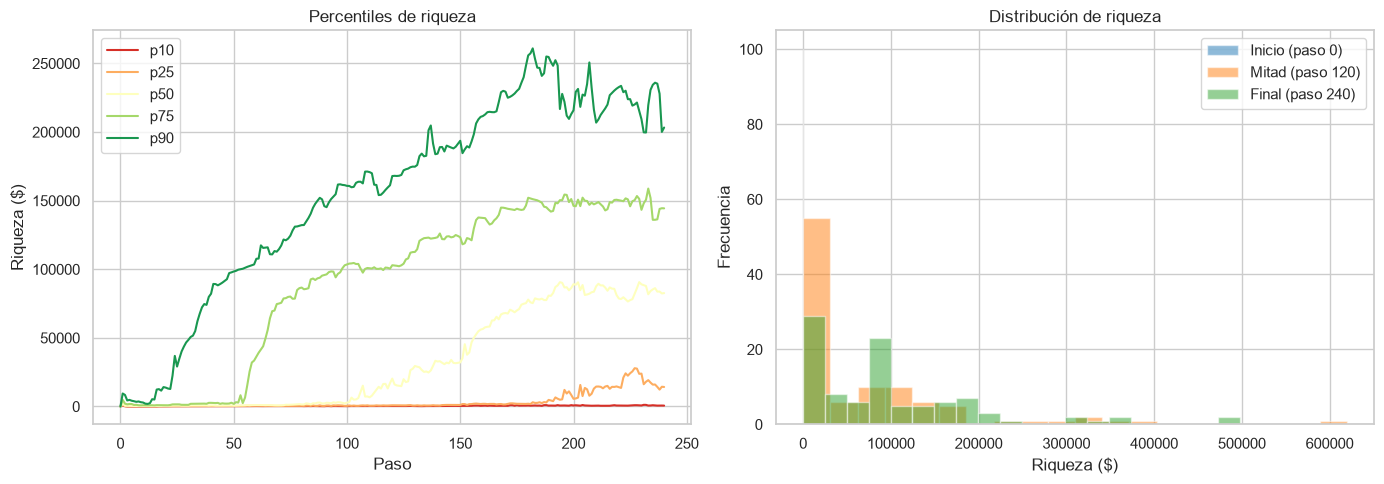

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentiles de riqueza a lo largo del tiempo
ax = axes[0]
quantiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(quantiles)))
for q, c in zip(quantiles, colors):
    ax.plot(np.percentile(wealth, q, axis=1), label=f'p{q}', color=c)
ax.set_title('Percentiles de riqueza')
ax.set_xlabel('Paso')
ax.set_ylabel('Riqueza ($)')
ax.legend()

# Distribución al inicio, mitad y final
ax = axes[1]
checkpoints = [0, T//2, T-1]
labels = ['Inicio', 'Mitad', 'Final']
for cp, label in zip(checkpoints, labels):
    ax.hist(wealth[cp], bins=20, alpha=0.5, label=f'{label} (paso {cp})')
ax.set_title('Distribución de riqueza')
ax.set_xlabel('Riqueza ($)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Coeficiente de Gini

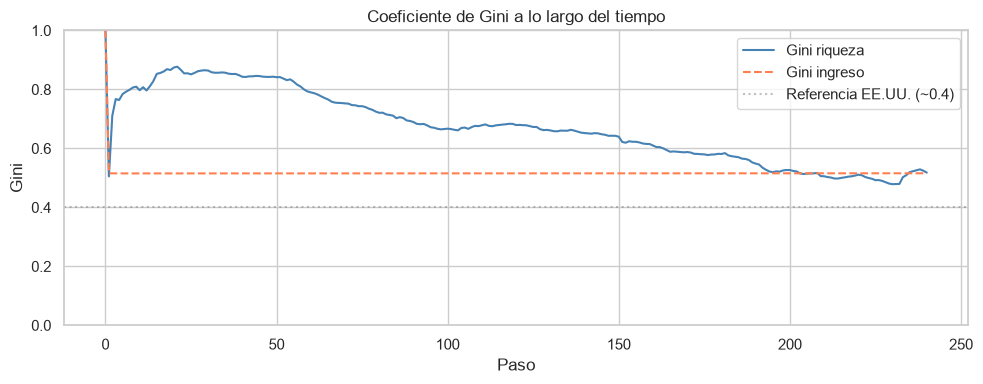

Gini riqueza  — inicio: 1.000  |  final: 0.518
Gini ingreso  — inicio: 1.000  |  final: 0.516


In [30]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return 1 - (2 / (n + 1)) * np.sum(np.cumsum(x) / (np.sum(x) + 1e-10))

gini_wealth = [gini(wealth[t]) for t in range(T)]
gini_income = [gini(income[t]) for t in range(T)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_wealth, label='Gini riqueza', color='steelblue')
ax.plot(gini_income, label='Gini ingreso', color='coral', linestyle='--')
ax.set_ylim(0, 1)
ax.set_title('Coeficiente de Gini a lo largo del tiempo')
ax.set_xlabel('Paso')
ax.set_ylabel('Gini')
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='Referencia EE.UU. (~0.4)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gini riqueza  — inicio: {gini_wealth[0]:.3f}  |  final: {gini_wealth[-1]:.3f}')
print(f'Gini ingreso  — inicio: {gini_income[0]:.3f}  |  final: {gini_income[-1]:.3f}')

## 6. Curva de Lorenz (inicio vs final)

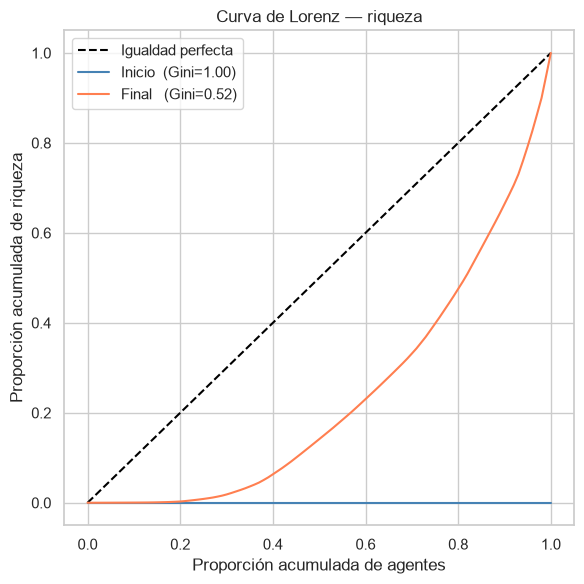

In [31]:
def lorenz(x):
    x = np.sort(np.abs(x))
    cum = np.cumsum(x) / (np.sum(x) + 1e-10)
    return np.concatenate([[0], cum])

fig, ax = plt.subplots(figsize=(6, 6))
pop = np.linspace(0, 1, n_agents + 1)

ax.plot([0, 1], [0, 1], 'k--', label='Igualdad perfecta')
ax.plot(pop, lorenz(wealth[0]),   label=f'Inicio  (Gini={gini_wealth[0]:.2f})',  color='steelblue')
ax.plot(pop, lorenz(wealth[-1]),  label=f'Final   (Gini={gini_wealth[-1]:.2f})', color='coral')

ax.set_title('Curva de Lorenz — riqueza')
ax.set_xlabel('Proporción acumulada de agentes')
ax.set_ylabel('Proporción acumulada de riqueza')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Actividad laboral y consumo

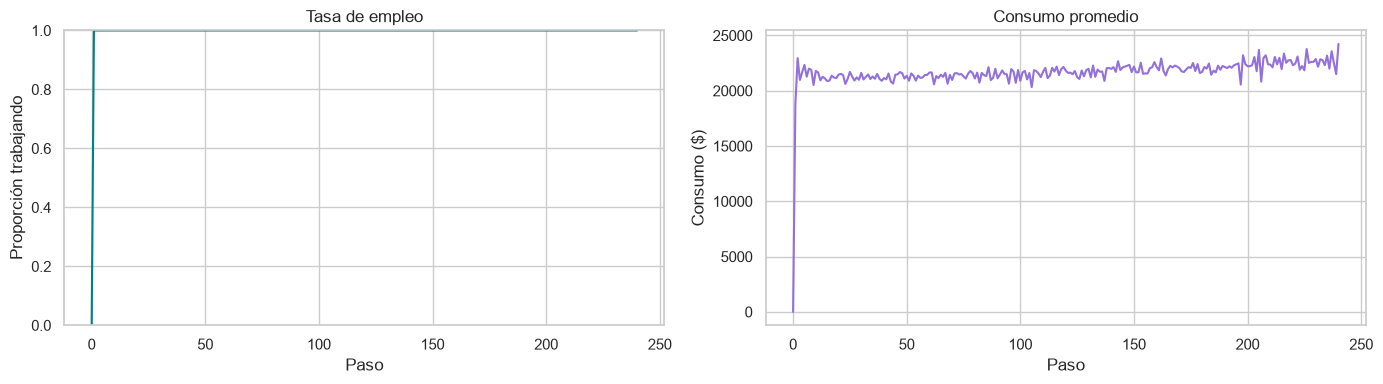

In [32]:
# Tasa de empleo: proporción de agentes que trabajaron en cada paso
if 'SimpleLabor' in log:
    labor_log = log['SimpleLabor']
    labor_rate = [np.mean([a > 0 for a in step.values()]) if isinstance(step, dict) else np.mean(np.array(step) > 0) for step in labor_log]
else:
    labor_rate = [np.mean(income[t] > 0) for t in range(T)]

# Consumo promedio
consumption = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
mean_consumption = consumption.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(labor_rate, color='teal')
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de empleo')
axes[0].set_xlabel('Paso')
axes[0].set_ylabel('Proporción trabajando')

axes[1].plot(mean_consumption, color='mediumpurple')
axes[1].set_title('Consumo promedio')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Consumo ($)')

plt.tight_layout()
plt.show()

## 8. Impuestos y redistribución

In [33]:
tax_key = [k for k in log.keys() if 'BracketTax' in k and 'tax_paid' in k]
lump_key = [k for k in log.keys() if 'BracketTax' in k and 'lump_sum' in k]

if tax_key and lump_key:
    tax_data  = np.array(log[tax_key[0]])   # shape (T, n_agents) or similar
    lump_data = np.array(log[lump_key[0]])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(tax_data.mean(axis=-1) if tax_data.ndim > 1 else tax_data, color='tomato')
    axes[0].set_title('Impuesto promedio pagado')
    axes[0].set_xlabel('Paso')
    axes[0].set_ylabel('$ impuesto')

    axes[1].plot(lump_data.mean(axis=-1) if lump_data.ndim > 1 else lump_data, color='seagreen')
    axes[1].set_title('Lump-sum redistribuido (promedio)')
    axes[1].set_xlabel('Paso')
    axes[1].set_ylabel('$ recibido')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos de impuestos en el dense_log.')
    print('Claves disponibles:', [k for k in log.keys() if 'Tax' in k or 'tax' in k])

No se encontraron datos de impuestos en el dense_log.
Claves disponibles: ['PeriodicTax']


## 9. Resumen estadístico

In [34]:
summary = pd.DataFrame({
    'Riqueza media':       wealth.mean(axis=1),
    'Riqueza mediana':     np.median(wealth, axis=1),
    'Riqueza std':         wealth.std(axis=1),
    'Ingreso medio':       income.mean(axis=1),
    'Consumo medio':       mean_consumption,
    'Gini riqueza':        gini_wealth,
    'Gini ingreso':        gini_income,
})

print('=== Estadísticas al INICIO ===')
print(summary.iloc[0].to_string())
print('\n=== Estadísticas al FINAL ===')
print(summary.iloc[-1].to_string())

=== Estadísticas al INICIO ===
Riqueza media      0.0
Riqueza mediana    0.0
Riqueza std        0.0
Ingreso medio      0.0
Consumo medio      0.0
Gini riqueza       1.0
Gini ingreso       1.0

=== Estadísticas al FINAL ===
Riqueza media       98904.701170
Riqueza mediana     82628.858037
Riqueza std        101803.279390
Ingreso medio       23088.552334
Consumo medio       24238.853655
Gini riqueza            0.517845
Gini ingreso            0.515554


## 10. Curva de Phillips y Ley de Okun (validación vs. el paper)

El paper original usa estas dos regularidades como principal criterio de plausibilidad (Figura 3): correlación negativa entre desempleo e inflación salarial (Phillips) y entre crecimiento del desempleo y crecimiento del PIB real (Okun). Reportan Pearson r=-0.619 (p<0.01) y r=-0.918 (p<0.001) respectivamente para EconAgent con gpt-3.5-turbo-0613, muy superior a los baselines rule-based/RL.

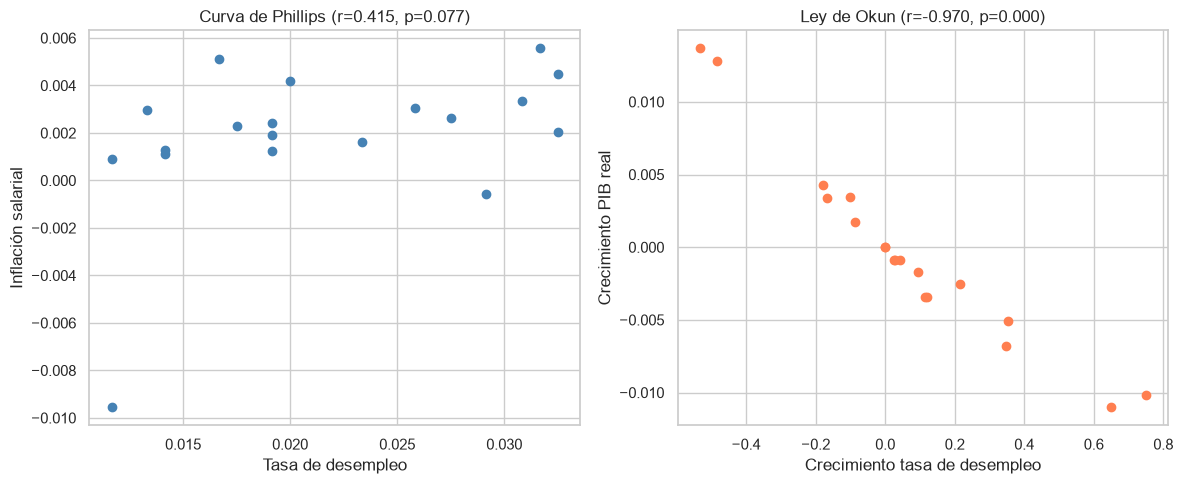

Phillips: r=0.415  p=0.0774   (paper gpt-3.5: r=-0.619, p<0.01)
Okun:     r=-0.970  p=0.0000   (paper gpt-3.5: r=-0.918, p<0.001)


In [35]:
from scipy.stats import pearsonr

unemp_a = world_df['Unemployment Rate'].dropna()
wage_infl_a = world_df['Wage Inflation'].dropna()
unemp_growth_a = world_df['Unemployment Rate Growth'].dropna()
gdp_growth_a = world_df['Real GDP Growth'].dropna()

# Alinear por índice (mismos steps anuales)
phillips = pd.concat([unemp_a, wage_infl_a], axis=1).dropna()
okun = pd.concat([unemp_growth_a, gdp_growth_a], axis=1).dropna()

r_phillips, p_phillips = pearsonr(phillips.iloc[:,0], phillips.iloc[:,1])
r_okun, p_okun = pearsonr(okun.iloc[:,0], okun.iloc[:,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(phillips.iloc[:,0], phillips.iloc[:,1], color='steelblue')
axes[0].set_title(f'Curva de Phillips (r={r_phillips:.3f}, p={p_phillips:.3f})')
axes[0].set_xlabel('Tasa de desempleo')
axes[0].set_ylabel('Inflación salarial')

axes[1].scatter(okun.iloc[:,0], okun.iloc[:,1], color='coral')
axes[1].set_title(f"Ley de Okun (r={r_okun:.3f}, p={p_okun:.3f})")
axes[1].set_xlabel('Crecimiento tasa de desempleo')
axes[1].set_ylabel('Crecimiento PIB real')

plt.tight_layout()
plt.show()

print(f'Phillips: r={r_phillips:.3f}  p={p_phillips:.4f}   (paper gpt-3.5: r=-0.619, p<0.01)')
print(f'Okun:     r={r_okun:.3f}  p={p_okun:.4f}   (paper gpt-3.5: r=-0.918, p<0.001)')

## 11. Comparación de rangos con el paper

El paper reporta (Figura 2, texto sección 4.2, con gpt-3.5-turbo-0613):
- Inflación anual: estable entre -5% y 5% después del año 3.
- Desempleo: generalmente entre 2% y 12%.
- PIB nominal y su crecimiento dentro de límites "razonables" (sin cuantificar rango exacto).

In [36]:
infl = world_df['Price Inflation'].dropna()
unemp = world_df['Unemployment Rate'].dropna()

print('=== Esta corrida (Nova Lite) ===')
print(f'Inflación anual:  min {infl.min():.3%}  max {infl.max():.3%}')
print(f'Desempleo anual:  min {unemp.min():.3%}  max {unemp.max():.3%}')
print()
print('=== Paper (gpt-3.5-turbo-0613) ===')
print('Inflación anual:  banda -5% a 5% (después del año 3)')
print('Desempleo anual:  banda ~2% a 12%')

=== Esta corrida (Nova Lite) ===
Inflación anual:  min -2.106%  max 1.578%
Desempleo anual:  min 1.167%  max 3.250%

=== Paper (gpt-3.5-turbo-0613) ===
Inflación anual:  banda -5% a 5% (después del año 3)
Desempleo anual:  banda ~2% a 12%
